In [3]:
# Standard NVAR = NG-RC

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import warnings

# Suppress noisy warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ============================================================
# 1. Reproducibility
# ============================================================
seed = 2025
np.random.seed(seed)

# ============================================================
# 2. Time Setup
# ============================================================
dt = np.float32(1.0)
warmup, traintime, valtime, testtime = (
    np.float32(500.0),
    np.float32(7500.0),
    np.float32(1000.0),
    np.float32(1000.0),
)
maxtime = warmup + traintime + valtime + testtime

# Convert to discrete steps (these remain Python ints for indexing)
warmup_pts = int(round(warmup / dt))
traintime_pts = int(round(traintime / dt))
valtime_pts = int(round(valtime / dt))
testtime_pts = int(round(testtime / dt))
warmtrain_pts = warmup_pts + traintime_pts
val_end = warmtrain_pts + valtime_pts
maxtime_pts = int(round(maxtime / dt))

print("==== Data Splits (time steps) ====")
print(f" Warmup : {warmup_pts}")
print(f" Train  : {traintime_pts}")
print(f" Val    : {valtime_pts}")
print(f" Test   : {testtime_pts}")
print(f" Total  : {maxtime_pts}\n")

# ============================================================
# 3. Load Data
# ============================================================
data_file = "ground_truth.npy"
X_soln = np.load(data_file).astype(np.float32)
d, T_full = X_soln.shape

X_soln = X_soln[:, : maxtime_pts + 1]
t_eval = np.linspace(0, maxtime, maxtime_pts + 1).astype(np.float32)

print(f"Loaded data shape: (d={d}, T={X_soln.shape[1]})")

# ============================================================
# 4. Add Noise
# ============================================================
def add_relative_gaussian_noise(X_clean, noise_scale):
    """Add Gaussian noise scaled by per-variable std."""
    # signal_std shape: (d,1)
    signal_std = np.std(X_clean, axis=1, keepdims=True).astype(np.float32)
    noise = np.random.normal(
        0.0, (noise_scale * signal_std).astype(np.float32), size=X_clean.shape
    ).astype(np.float32)
    return (X_clean + noise).astype(np.float32)


noise_scale = np.float32(0.20)  # Noise free case
X_noisy = add_relative_gaussian_noise(X_soln, noise_scale=noise_scale)

print("\n==== Noise Check ====")
print(" Before (first 5):", X_soln[0, :5])
print(" After  (first 5):", X_noisy[0, :5])
print(" Mean abs diff   :", np.mean(np.abs(X_noisy - X_soln)), "\n")

# ============================================================
# 5. Model Parameters
# ============================================================
k_values = [2, 10, 30, 50]
ridge_values = [
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
    1e1,
    1e2,
    1e3,
    1e4,
]
results = []

# ============================================================
# 6. Feature Construction
# ============================================================
def build_features(data, k, start_idx, end_idx):
    """
    Construct features for regression:
    - Linear block: k delays per variable
    - Quadratic block: all pairwise products
    Returns:
        out       : (dtot, L) feature matrix
        lin_block : (d*k, L) stacked linear delays
    """
    d_local, T = data.shape
    assert start_idx >= k - 1, "start_idx must be >= k-1"

    length = end_idx - start_idx
    dlin = k * d_local
    dnonlin = (dlin * (dlin + 1)) // 2
    dtot = 1 + dlin + dnonlin

    # Linear delay block (float32)
    lin_block = np.zeros((dlin, length), dtype=np.float32)
    for i, t in enumerate(range(start_idx, end_idx)):
        lin_block[:, i] = np.hstack(
            [data[:, t - delay] for delay in range(k)]
        ).astype(np.float32)

    # Initialize feature matrix (float32)
    out = np.ones((dtot, length), dtype=np.float32)
    out[1 : 1 + dlin, :] = lin_block

    # Quadratic features
    cnt = 0
    for r in range(dlin):
        for c in range(r, dlin):
            out[1 + dlin + cnt, :] = lin_block[r, :] * lin_block[c, :]
            cnt += 1

    return out.astype(np.float32), lin_block.astype(np.float32)


# ============================================================
# 7. Grid Search
# ============================================================
window_size = 100
print("==== Grid Search Results ====")
for k, ridge_param in itertools.product(k_values, ridge_values):
    dlin = k * d
    dnonlin = dlin * (dlin + 1) // 2
    dtot = 1 + dlin + dnonlin

    # --- Training ---
    start_feat = warmup_pts - 1
    end_feat = warmtrain_pts - 1
    if start_feat < (k - 1):
        raise ValueError("Not enough history for chosen k in training")

    out_train, _ = build_features(X_noisy, k, start_feat, end_feat)

    delta_x = (
        X_noisy[:, warmup_pts:warmtrain_pts]
        - X_noisy[:, warmup_pts - 1 : warmtrain_pts - 1]
    ).astype(np.float32)

    C = (out_train @ out_train.T).astype(np.float32)
    regularizer = (ridge_param * np.eye(C.shape[0], dtype=np.float32)).astype(
        np.float32
    )
    # Stable solve (avoid pinv if possible)
    try:
        W_out = (
            delta_x
            @ out_train.T
            @ np.linalg.solve(C + regularizer, np.eye(C.shape[0], dtype=np.float32))
        )
    except np.linalg.LinAlgError:
        W_out = (
            delta_x @ out_train.T @ np.linalg.pinv((C + regularizer).astype(np.float32))
        )
    W_out = W_out.astype(np.float32)

    # --- Validation ---
    rmses = []
    for start in range(warmtrain_pts, val_end, window_size):
        end = min(start + window_size, val_end)
        if end - start < window_size:
            continue

        # initial history
        if start - k < 0:
            raise ValueError("Not enough warmup history for validation start")
        history = [
            X_noisy[:, start - k + i].copy().astype(np.float32) for i in range(k)
        ]

        # rollout predictions (float32)
        pred = np.zeros((d, window_size), dtype=np.float32)
        for j in range(window_size):
            z = np.hstack([history[-1 - i] for i in range(k)]).astype(np.float32)
            out_test = np.ones((dtot, 1), dtype=np.float32)
            out_test[1:1 + dlin, 0] = z

            cnt = 0
            for r in range(dlin):
                for c in range(r, dlin):
                    out_test[1 + dlin + cnt, 0] = z[r] * z[c]
                    cnt += 1

            delta_pred = (W_out @ out_test).reshape(d).astype(np.float32)
            next_x = (history[-1] + delta_pred).astype(np.float32)
            pred[:, j] = next_x
            history.append(next_x)

        true = X_soln[:, start:end].astype(np.float32)
        rmses.append(np.sqrt(np.mean((true - pred) ** 2)).astype(np.float32))

    avg_rmse = np.mean(rmses).astype(np.float32) if rmses else np.inf
    results.append((k, ridge_param, float(avg_rmse)))

    print(f" k={k:<2d} | ridge={ridge_param:>6.1e} | Avg Val RMSE={avg_rmse:.6f}")



==== Data Splits (time steps) ====
 Warmup : 500
 Train  : 7500
 Val    : 1000
 Test   : 1000
 Total  : 10000

Loaded data shape: (d=1, T=10001)

==== Noise Check ====
 Before (first 5): [0.         0.00275208 0.01004922 0.01578102 0.01801591]
 After  (first 5): [-0.00443748  0.03801965 -0.05905996 -0.01608298  0.01317796]
 Mean abs diff   : 0.03835463 

==== Grid Search Results ====
 k=2  | ridge=1.0e-07 | Avg Val RMSE=0.228800
 k=2  | ridge=1.0e-06 | Avg Val RMSE=0.228800
 k=2  | ridge=1.0e-05 | Avg Val RMSE=0.228800
 k=2  | ridge=1.0e-04 | Avg Val RMSE=0.228800
 k=2  | ridge=1.0e-03 | Avg Val RMSE=0.228988
 k=2  | ridge=1.0e-02 | Avg Val RMSE=0.229111
 k=2  | ridge=1.0e-01 | Avg Val RMSE=0.229882
 k=2  | ridge=1.0e+00 | Avg Val RMSE=0.231046
 k=2  | ridge=1.0e+01 | Avg Val RMSE=0.231720
 k=2  | ridge=1.0e+02 | Avg Val RMSE=0.234341
 k=2  | ridge=1.0e+03 | Avg Val RMSE=0.282350
 k=2  | ridge=1.0e+04 | Avg Val RMSE=0.432033
 k=10 | ridge=1.0e-07 | Avg Val RMSE=0.195819
 k=10 | ridge=1

/tmp/ipython-input-3185414768.py:201: RuntimeWarning: overflow encountered in scalar multiply
  out_test[1 + dlin + cnt, 0] = z[r] * z[c]
/tmp/ipython-input-3185414768.py:204: RuntimeWarning: invalid value encountered in matmul
  delta_pred = (W_out @ out_test).reshape(d).astype(np.float32)
/tmp/ipython-input-3185414768.py:210: RuntimeWarning: overflow encountered in square
  rmses.append(np.sqrt(np.mean((true - pred) ** 2)).astype(np.float32))
/tmp/ipython-input-3185414768.py:204: RuntimeWarning: overflow encountered in matmul
  delta_pred = (W_out @ out_test).reshape(d).astype(np.float32)


 k=50 | ridge=1.0e-07 | Avg Val RMSE=nan
 k=50 | ridge=1.0e-06 | Avg Val RMSE=nan
 k=50 | ridge=1.0e-05 | Avg Val RMSE=nan
 k=50 | ridge=1.0e-04 | Avg Val RMSE=nan
 k=50 | ridge=1.0e-03 | Avg Val RMSE=nan
 k=50 | ridge=1.0e-02 | Avg Val RMSE=0.055987
 k=50 | ridge=1.0e-01 | Avg Val RMSE=0.056628
 k=50 | ridge=1.0e+00 | Avg Val RMSE=0.059431
 k=50 | ridge=1.0e+01 | Avg Val RMSE=0.063574
 k=50 | ridge=1.0e+02 | Avg Val RMSE=0.087453
 k=50 | ridge=1.0e+03 | Avg Val RMSE=0.125167
 k=50 | ridge=1.0e+04 | Avg Val RMSE=0.138041


In [5]:
# ============================================================
# 1. Select Best Model
# ============================================================
valid_results = [(k, ridge, rmse) for (k, ridge, rmse) in results if np.isfinite(rmse)]
if not valid_results:
    raise RuntimeError("No valid results found (all NaN/inf). Check model stability.")

best_k, best_ridge, best_rmse = min(valid_results, key=lambda x: x[2])

print("\n==== Best Model ====")
print(
    f"k = {best_k}, ridge = {best_ridge:.2e} → Avg. Validation RMSE = {best_rmse:.6f}\n"
)

# ============================================================
# 2. Retrain on TRAIN only (using Best Hyperparameters)
# ============================================================
start_feat = warmup_pts - 1
end_feat = warmtrain_pts - 1  # stop at TRAIN, not VAL
out_train, lin_train = build_features(X_noisy, best_k, start_feat, end_feat)

delta_x = (
    X_noisy[:, warmup_pts:warmtrain_pts]
    - X_noisy[:, warmup_pts - 1 : warmtrain_pts - 1]
).astype(np.float32)
C = (out_train @ out_train.T).astype(np.float32)
W_out = (
    delta_x
    @ out_train.T
    @ np.linalg.pinv((C + best_ridge * np.eye(C.shape[0], dtype=np.float32)).astype(np.float32))
)
W_out = W_out.astype(np.float32)

# ============================================================
# 3. Test on Non-overlapping Windows (after VAL)
# ============================================================
test_start, test_end = val_end, maxtime_pts
window_size = 100

all_true, all_pred, all_t, all_rmse = [], [], [], []

horizons = [25, 50, 75, 100]
horizon_rmses = {h: [] for h in horizons}

dlin = best_k * d
dnonlin = (dlin * (dlin + 1)) // 2
dtot = 1 + dlin + dnonlin

for start in range(test_start, test_end, window_size):
    end = min(start + window_size, test_end)
    if end - start < window_size:
        continue

    # Initialize history with last k noisy points
    if start - best_k < 0:
        raise ValueError("Not enough history for test start")
    history = [
        X_noisy[:, start - best_k + i].copy().astype(np.float32) for i in range(best_k)
    ]

    pred = np.zeros((d, window_size), dtype=np.float32)
    for j in range(window_size):
        z = np.hstack([history[-1 - i] for i in range(best_k)]).astype(np.float32)
        out_test = np.ones((dtot, 1), dtype=np.float32)
        out_test[1:1 + dlin, 0] = z

        cnt = 0
        for r in range(dlin):
            for c in range(r, dlin):
                out_test[1 + dlin + cnt, 0] = z[r] * z[c]
                cnt += 1

        delta_pred = (W_out @ out_test).reshape(d).astype(np.float32)
        next_x = (history[-1] + delta_pred).astype(np.float32)
        pred[:, j] = next_x
        history.append(next_x)

    true = X_soln[:, start:end].astype(np.float32)

    # Horizon RMSEs
    for h in horizons:
        if h <= pred.shape[1]:
            rmse_h = np.sqrt(np.mean((true[:, :h] - pred[:, :h]) ** 2, axis=1)).astype(
                np.float32
            )
            horizon_rmses[h].append(rmse_h)

    rmse_full = np.sqrt(np.mean((true - pred) ** 2)).astype(np.float32)
    all_rmse.append((start, end, float(rmse_full)))

    all_true.append(true)
    all_pred.append(pred)
    all_t.extend(list(range(start, end)))

all_true = np.hstack(all_true).astype(np.float32) if all_true else np.empty((d, 0), dtype=np.float32)
all_pred = np.hstack(all_pred).astype(np.float32) if all_pred else np.empty((d, 0), dtype=np.float32)

# ============================================================
# 4. Horizon-wise RMSE Summary
# ============================================================
print("\n==== Horizon-wise RMSE Summary ====")
for h in horizons:
    if len(horizon_rmses[h]) == 0:
        continue
    rmse_arr = np.vstack(horizon_rmses[h]).astype(np.float32)  # (num_windows, d)
    mean_per_var = np.mean(rmse_arr, axis=0).astype(np.float32)
    overall = np.mean(mean_per_var).astype(np.float32)
    print(f"\n-- Horizon {h} steps --")
    # original script printed only one variable 'x' for display; keep same behavior
    for i, v in enumerate(["x"]):
        print(f"Variable {v}: RMSE = {mean_per_var[i]:.6f}")
    print(f"Overall avg. RMSE = {overall:.6f}")





==== Best Model ====
k = 50, ridge = 1.00e-02 → Avg. Validation RMSE = 0.055987


==== Horizon-wise RMSE Summary ====

-- Horizon 25 steps --
Variable x: RMSE = 0.040233
Overall avg. RMSE = 0.040233

-- Horizon 50 steps --
Variable x: RMSE = 0.047298
Overall avg. RMSE = 0.047298

-- Horizon 75 steps --
Variable x: RMSE = 0.059715
Overall avg. RMSE = 0.059715

-- Horizon 100 steps --
Variable x: RMSE = 0.071404
Overall avg. RMSE = 0.071404


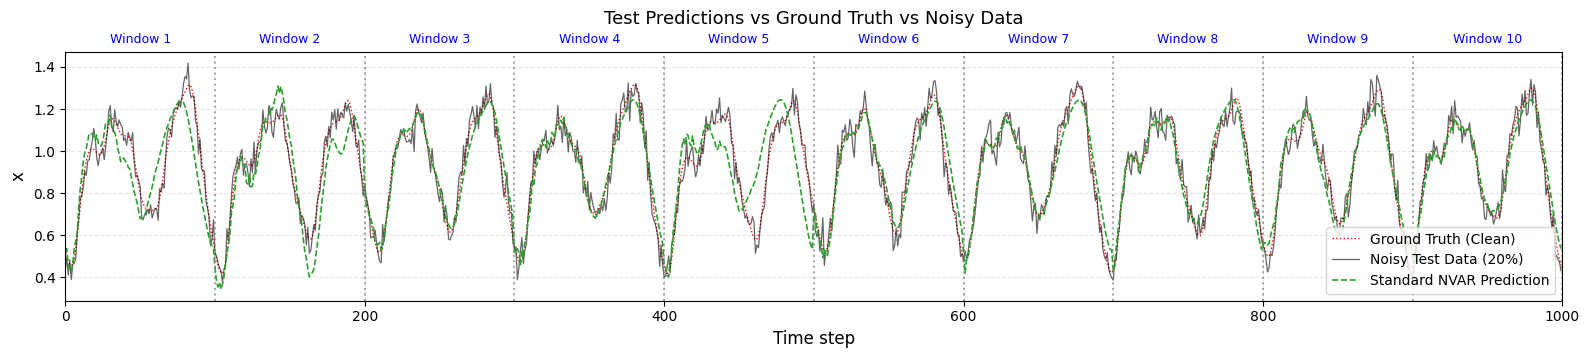

Saved plot as: Test_pred_vs_truth_k50_ridge1.0e-02_noise0.20.png


In [6]:
# ============================================================
# 5. Plot
# ============================================================
# Make relative time axis starting at 0
t_rel = np.arange(all_true.shape[1], dtype=np.float32)

plt.figure(figsize=(16, 4))

# Ground truth
plt.plot(t_rel, all_true[0].astype(np.float32), color="red", linestyle=":", linewidth=1.0, label="Ground Truth (Clean)")

# Noisy observations
plt.plot(t_rel, X_noisy[0, np.array(all_t)].astype(np.float32), color="black", linewidth=0.9, alpha=0.6, label=f"Noisy Test Data ({noise_scale*100:.0f}%)")

# Predictions
plt.plot(t_rel, all_pred[0].astype(np.float32), color="C2", linestyle="--", linewidth=1.2, label="Standard NVAR Prediction")

# Window boundaries + labels (shift to relative index)
ylim = plt.ylim()
for idx, (start, end, rmse) in enumerate(all_rmse, 1):
    rel_end = end - test_start  # shift so first test step = 0
    plt.axvline(rel_end, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
    plt.text((rel_end + (rel_end - window_size)) / 2, ylim[1] * 1.02, f"Window {idx}", ha="center", va="bottom", fontsize=9, color="blue")

# Labels and title
plt.xlabel("Time step", fontsize=12)
plt.ylabel("x", fontsize=12)
plt.title("Test Predictions vs Ground Truth vs Noisy Data", fontsize=13, pad=20)

# Grid and legend
plt.grid(alpha=0.3, linestyle="--")
plt.legend()

# Force x-axis from 0 to 1000
plt.xlim(0, 1000)
plt.tight_layout(rect=[0, 0.08, 1, 1])

# Save and show
filename = f"Test_pred_vs_truth_k{best_k}_ridge{best_ridge:.1e}_noise{noise_scale:.2f}.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot as: {filename}")

In [7]:
# ================================
# Save full NVAR predictions as .npy file (FULL FLOAT32)
# ================================

save_info = {
    "NVAR_predictions_full": all_pred.astype(np.float32),
    "true_test": all_true.astype(np.float32),
    "X_test_noisy": X_noisy[:, np.array(all_t)].astype(np.float32),

    # Scalars stored as float32 (not Python float64)
    "noise_scale": np.float32(noise_scale),
    "best_k": np.int32(best_k),
    "best_ridge": np.float32(best_ridge),
    "window_size": np.int32(window_size),
    "dt": np.float32(dt),
    "feature_dim": np.int32(dtot),
}

# Informative filename encoding key parameters
save_name = (
    f"NVAR_pred_k{best_k}_"
    f"ridge{best_ridge:.1e}_"
    f"noise{noise_scale:.2f}_"
    f"winsize{window_size}_"
    f"dt{dt:.2f}.npy"
)

np.save(save_name, save_info)
print(f"Saved NVAR predictions and metadata as: {save_name}")


Saved NVAR predictions and metadata as: NVAR_pred_k50_ridge1.0e-02_noise0.20_winsize100_dt1.00.npy
